# Module 1 — Claim Occurrence Classification with Probability Calibration

## Business Context

We predict **whether a policy will generate a claim** (binary: `HasClaim`). Well-calibrated
probability scores drive **Straight-Through Processing (STP)** routing:

| Lane | Probability | Action |
|------|-------------|--------|
| `auto-settle` | p < 0.10 | Instant payout — no human review |
| `review` | 0.10 ≤ p < 0.40 | Manual adjuster assessment |
| `investigate` | p ≥ 0.40 | Detailed investigation / fraud referral |

We compare **Logistic Regression**, **Random Forest**, and **CatBoost**, then apply
Platt scaling and isotonic calibration, tracking results in **MLflow**.

## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

from claims.data import load_fremtpl2, build_claims_dataset, split_dataset
from claims.features import (
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    ENG_NUMERIC_FEATURES,
    TARGET_COL,
    get_feature_names,
    engineer_features,
)
from claims.classification.models import (
    logistic_pipeline,
    random_forest_pipeline,
    catboost_classifier,
    compute_scale_pos_weight,
)
from claims.classification.calibration import (
    calibrate,
    calibration_metrics,
    plot_reliability_diagram,
)
from claims.evaluation import (
    classification_report_dict,
    gini_coefficient,
    stp_routing,
    stp_summary,
    gains_chart,
    lift_chart,
    decile_analysis,
    plot_gains_lift,
)

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Setup complete.')

Setup complete.


In [ ]:
from pathlib import Path
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figures → {FIG_DIR.resolve()}")

## 2. Data Preparation

In [3]:
# Load and join the two freMTPL2 tables
print('Loading freMTPL2 from OpenML...')
freq, sev = load_fremtpl2()
df = build_claims_dataset(freq, sev)
print(f'Dataset shape: {df.shape}')
df.head(3)
df = engineer_features(df)
print(f"After engineering: {df.shape}")


Loading freMTPL2 from OpenML...


Dataset shape: (678013, 18)
After engineering: (678013, 24)


In [4]:
# Stratified train / test split on HasClaim
train_df, test_df = split_dataset(df, target='HasClaim', test_size=0.2, random_state=RANDOM_STATE)
print(f'Train size : {len(train_df):,}  |  Test size: {len(test_df):,}')

# Class imbalance statistics
print()
print('=== Class Imbalance (Train) ===')
y_train_counts = train_df['HasClaim'].value_counts()
print(f"  No claim  (0): {y_train_counts[0]:>8,}  ({y_train_counts[0]/len(train_df)*100:.2f}%)")
print(f"  Has claim (1): {y_train_counts[1]:>8,}  ({y_train_counts[1]/len(train_df)*100:.2f}%)")
print(f"  Imbalance ratio: {y_train_counts[0]/y_train_counts[1]:.1f}:1")

Train size : 542,410  |  Test size: 135,603

=== Class Imbalance (Train) ===
  No claim  (0):  515,162  (94.98%)
  Has claim (1):   27,248  (5.02%)
  Imbalance ratio: 18.9:1


## 3. Feature Matrices

In [5]:
# Feature and target arrays
all_features = ENG_NUMERIC_FEATURES + CATEGORICAL_FEATURES
print(f'Numeric features    ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}')
print(f'Categorical features({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}')
print()

# X as DataFrame (required for CatBoost with cat_features as column names)
X_train = train_df[all_features].copy()
X_test  = test_df[all_features].copy()

y_train = train_df[TARGET_COL].values
y_test  = test_df[TARGET_COL].values

print(f'X_train shape: {X_train.shape}  |  X_test shape: {X_test.shape}')
print(f'y_train positives: {y_train.sum():,} / {len(y_train):,}')

Numeric features    (5): ['VehAge', 'DrivAge', 'BonusMalus', 'Density', 'Exposure']
Categorical features(5): ['VehBrand', 'VehGas', 'Area', 'Region', 'VehPower']

X_train shape: (542410, 15)  |  X_test shape: (135603, 15)
y_train positives: 27,248 / 542,410


## 4. Logistic Regression Baseline

In [6]:
print('Fitting Logistic Regression...')
lr_pipe = logistic_pipeline(class_weight='balanced', C=1.0)
lr_pipe.fit(X_train, y_train)
print('Done.')

Fitting Logistic Regression...


Done.


In [7]:
lr_prob = lr_pipe.predict_proba(X_test)[:, 1]
lr_metrics = classification_report_dict(y_test, lr_prob)

print('=== Logistic Regression — Test Metrics ===')
for k, v in lr_metrics.items():
    print(f'  {k:20s}: {v:.4f}')

=== Logistic Regression — Test Metrics ===
  roc_auc             : 0.6415
  avg_precision       : 0.0909
  brier_score         : 0.2347
  cohen_kappa         : 0.0417
  gini                : 0.2830


## 5. Random Forest

In [8]:
print('Fitting Random Forest (n_estimators=300, max_depth=8)...')
rf_pipe = random_forest_pipeline(n_estimators=300, max_depth=8, class_weight='balanced')
rf_pipe.fit(X_train, y_train)
print('Done.')

Fitting Random Forest (n_estimators=300, max_depth=8)...


Done.


In [9]:
rf_prob = rf_pipe.predict_proba(X_test)[:, 1]
rf_metrics = classification_report_dict(y_test, rf_prob)

print('=== Random Forest — Test Metrics ===')
for k, v in rf_metrics.items():
    print(f'  {k:20s}: {v:.4f}')

=== Random Forest — Test Metrics ===
  roc_auc             : 0.6932
  avg_precision       : 0.1260
  brier_score         : 0.2195
  cohen_kappa         : 0.0634
  gini                : 0.3864


## 6. CatBoost

In [10]:
# Compute class imbalance weight
spw = compute_scale_pos_weight(y_train)
print(f'scale_pos_weight = {spw:.2f}  (n_neg / n_pos)')

scale_pos_weight = 18.91  (n_neg / n_pos)


In [11]:
# CatBoost receives raw string categoricals in a DataFrame
# cat_features passed as list of column names (CatBoost supports this when X is a DataFrame)
print('Fitting CatBoost (Optuna-tuned: iterations=866, lr=0.088, depth=7, l2_leaf_reg=4.04)...')
cb_model = catboost_classifier(
    scale_pos_weight=spw,
    verbose=0,
)

# Pass X as DataFrame with raw categorical strings; use column names as cat_features
cb_model.fit(
    X_train,
    y_train,
    cat_features=CATEGORICAL_FEATURES,
    eval_set=(X_test, y_test),
    verbose=False,
)
print('Done.')

Fitting CatBoost (Optuna-tuned: iterations=866, lr=0.088, depth=7, l2_leaf_reg=4.04)...


Done.


In [12]:
cb_prob = cb_model.predict_proba(X_test)[:, 1]
cb_metrics = classification_report_dict(y_test, cb_prob)

print('=== CatBoost — Test Metrics ===')
for k, v in cb_metrics.items():
    print(f'  {k:20s}: {v:.4f}')

=== CatBoost — Test Metrics ===
  roc_auc             : 0.7092
  avg_precision       : 0.1425
  brier_score         : 0.2089
  cohen_kappa         : 0.0762
  gini                : 0.4184


## 7. Probability Calibration

In [13]:
# Hold out a calibration split from the training set
from sklearn.model_selection import train_test_split as tts

X_cal_tr, X_val, y_cal_tr, y_val = tts(
    X_train, y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train,
)
print(f'Calibration train  : {len(X_cal_tr):,}')
print(f'Calibration holdout: {len(X_val):,}')

Calibration train  : 433,928
Calibration holdout: 108,482


In [14]:
# Re-fit CatBoost on the reduced calibration training split
print('Fitting CatBoost on calibration training split...')
cb_cal_base = catboost_classifier(
    scale_pos_weight=spw, verbose=0
)
cb_cal_base.fit(
    X_cal_tr, y_cal_tr,
    cat_features=CATEGORICAL_FEATURES,
    eval_set=(X_val, y_val),
    verbose=False,
)

# Post-hoc calibration: all four methods on the held-out validation set
cb_sigmoid  = calibrate(cb_cal_base, X_val, y_val, method='sigmoid')
cb_isotonic = calibrate(cb_cal_base, X_val, y_val, method='isotonic')
cb_beta     = calibrate(cb_cal_base, X_val, y_val, method='beta')
cb_venn     = calibrate(cb_cal_base, X_val, y_val, method='venn_abers')
print('All four calibrated models fitted: Sigmoid, Isotonic, Beta, Venn-ABERS.')

Fitting CatBoost on calibration training split...


All four calibrated models fitted: Sigmoid, Isotonic, Beta, Venn-ABERS.


In [15]:
# Calibration metrics on the test set — all four methods
prob_uncal   = cb_cal_base.predict_proba(X_test)[:, 1]
prob_sigmoid = cb_sigmoid.predict_proba(X_test)[:, 1]
prob_isoton  = cb_isotonic.predict_proba(X_test)[:, 1]
prob_beta    = cb_beta.predict_proba(X_test)[:, 1]
prob_venn    = cb_venn.predict_proba(X_test)[:, 1]

print('=== Calibration Metrics (ECE / MCE) — Test Set ===')
for label, prob in [
    ('Uncalibrated',    prob_uncal),
    ('Sigmoid (Platt)', prob_sigmoid),
    ('Isotonic',        prob_isoton),
    ('Beta',            prob_beta),
    ('Venn-ABERS',      prob_venn),
]:
    m = calibration_metrics(y_test, prob)
    print(f'  {label:20s}  ECE={m["ece"]:.4f}  MCE={m["mce"]:.4f}')

=== Calibration Metrics (ECE / MCE) — Test Set ===
  Uncalibrated          ECE=0.3808  MCE=0.5985
  Sigmoid (Platt)       ECE=0.0019  MCE=0.0811
  Isotonic              ECE=0.0006  MCE=0.0460
  Beta                  ECE=0.0005  MCE=0.2564
  Venn-ABERS            ECE=0.0008  MCE=0.4167


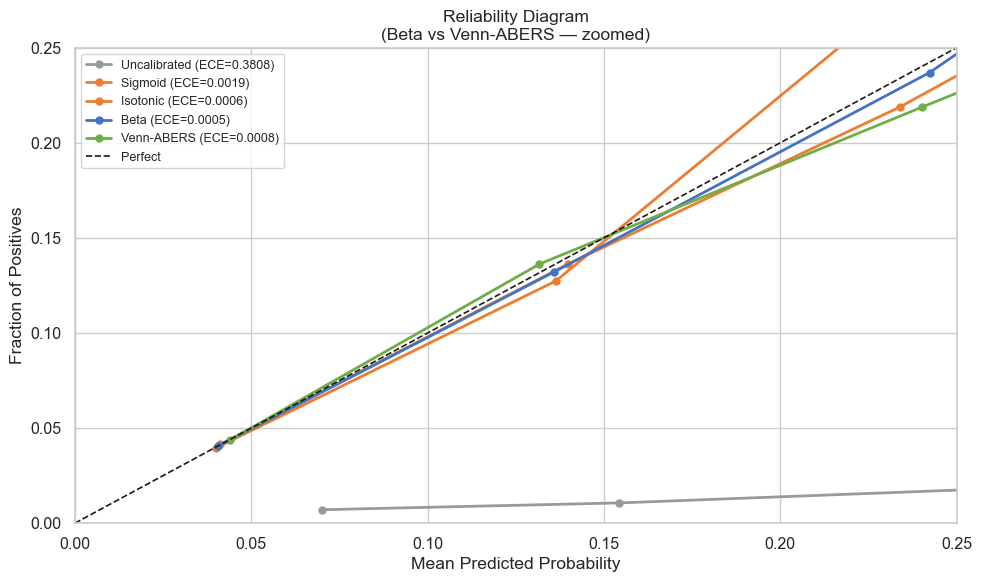

In [16]:
# Reliability diagram — all four calibration methods vs uncalibrated
ax = plot_reliability_diagram({
    'Uncalibrated': (y_test, prob_uncal),
    'Sigmoid':      (y_test, prob_sigmoid),
    'Isotonic':     (y_test, prob_isoton),
    'Beta':         (y_test, prob_beta),
    'Venn-ABERS':   (y_test, prob_venn),
}, n_bins=10, zoom_max=0.25, figsize=(10, 6))
plt.tight_layout()
ax.get_figure().savefig(FIG_DIR / "02_reliability_diagram.png", bbox_inches="tight", dpi=130)
plt.show()

## 8. Model Comparison Table

=== Model Comparison ===


,ROC-AUC,Brier Score,Cohen Kappa,Gini,ECE
Model,,,,,
Logistic Regression,0.6415,0.2347,0.0417,0.2830,0.4225
Random Forest,0.6932,0.2195,0.0634,0.3864,0.4627
CatBoost,0.7092,0.2089,0.0762,0.4184,0.3835
CatBoost + Sigmoid,0.7077,0.0457,0.0000,0.4154,0.0019
CatBoost + Isotonic,0.7074,0.0457,0.0029,0.4147,0.0006
CatBoost + Beta,0.7077,0.0457,0.0047,0.4154,0.0005
CatBoost + Venn-ABERS,0.6623,0.0466,0.0002,0.3245,0.0008


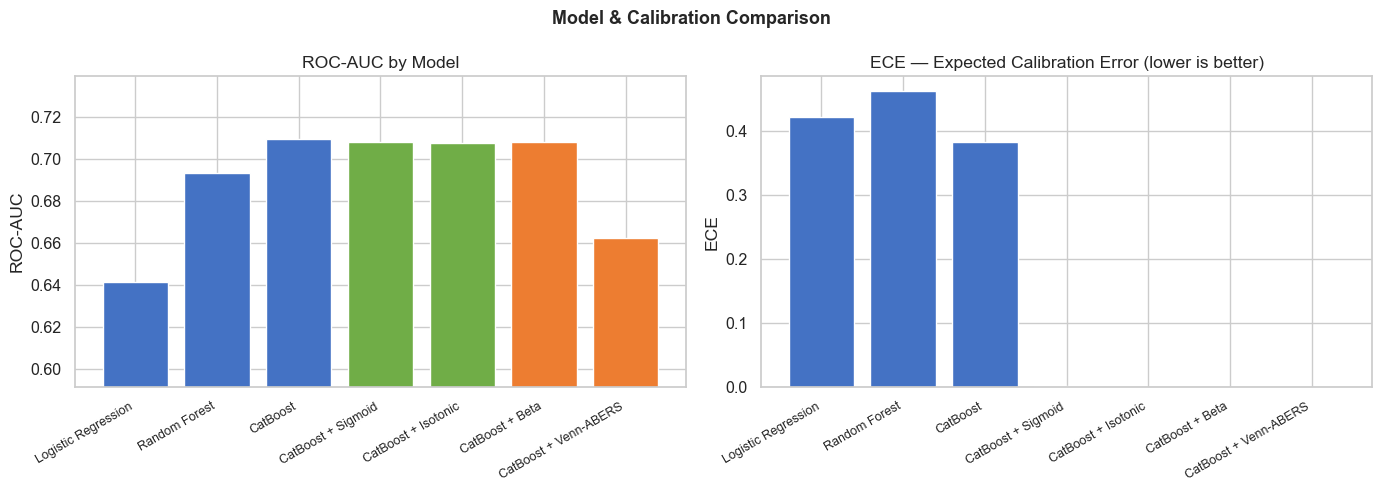

In [17]:
# Collect calibration ECE for each model
def _ece(y, p):
    return calibration_metrics(y, p)['ece']

rows = []
model_registry = [
    ('Logistic Regression',   lr_metrics,                                       lr_prob),
    ('Random Forest',         rf_metrics,                                       rf_prob),
    ('CatBoost',              cb_metrics,                                       cb_prob),
    ('CatBoost + Sigmoid',    classification_report_dict(y_test, prob_sigmoid), prob_sigmoid),
    ('CatBoost + Isotonic',   classification_report_dict(y_test, prob_isoton),  prob_isoton),
    ('CatBoost + Beta',       classification_report_dict(y_test, prob_beta),    prob_beta),
    ('CatBoost + Venn-ABERS', classification_report_dict(y_test, prob_venn),    prob_venn),
]

for name, metrics, prob in model_registry:
    rows.append({
        'Model'       : name,
        'ROC-AUC'     : round(metrics['roc_auc'], 4),
        'Brier Score' : round(metrics['brier_score'], 4),
        'Cohen Kappa' : round(metrics['cohen_kappa'], 4),
        'Gini'        : round(metrics['gini'], 4),
        'ECE'         : round(_ece(y_test, prob), 4),
    })

comparison_df = pd.DataFrame(rows).set_index('Model')
print('=== Model Comparison ===')
display(comparison_df)

# Bar chart — save as figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_names = [r['Model'] for r in rows]
aucs  = [r['ROC-AUC'] for r in rows]
eces  = [r['ECE'] for r in rows]
x     = np.arange(len(model_names))
bar_colors = ['#4472C4'] * 3 + ['#70AD47'] * 2 + ['#ED7D31'] * 2

axes[0].bar(x, aucs, color=bar_colors)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
axes[0].set_title('ROC-AUC by Model')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_ylim(min(aucs) - 0.05, max(aucs) + 0.03)

axes[1].bar(x, eces, color=bar_colors)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
axes[1].set_title('ECE — Expected Calibration Error (lower is better)')
axes[1].set_ylabel('ECE')

plt.suptitle('Model & Calibration Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / "02_model_comparison.png", bbox_inches="tight", dpi=130)
plt.show()

=== Gains / Lift Summary ===
  Top 10% captures : 30.4% of claims
  Top 20% captures : 45.2% of claims
  Top-decile lift  : 3.04×


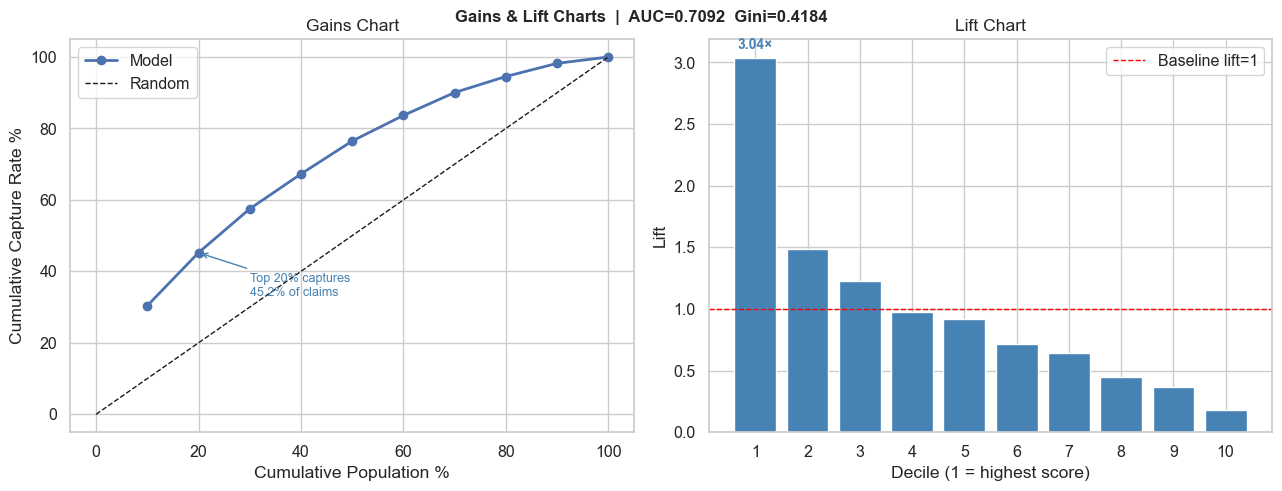

In [18]:
# Gains chart and lift chart (ranking power; calibration preserves ranking)
from sklearn.metrics import roc_auc_score as _roc_auc

gc = gains_chart(y_test, cb_prob, n_bins=10)
lc = lift_chart(y_test, cb_prob, n_bins=10)

auc_val  = _roc_auc(y_test, cb_prob)
gini_val = 2 * auc_val - 1

print("=== Gains / Lift Summary ===")
print(f"  Top 10% captures : {gc['cum_capture_rate'].iloc[0]:.1f}% of claims")
print(f"  Top 20% captures : {gc['cum_capture_rate'].iloc[1]:.1f}% of claims")
print(f"  Top-decile lift  : {lc['lift'].iloc[0]:.2f}×")

fig = plot_gains_lift(y_test, cb_prob, n_bins=10, figsize=(13, 5))

# Annotate gains chart
ax1 = fig.axes[0]
ax1.annotate(
    f"Top 20% captures\n{gc['cum_capture_rate'].iloc[1]:.1f}% of claims",
    xy=(gc["cum_exposure_pct"].iloc[1], gc["cum_capture_rate"].iloc[1]),
    xytext=(30, gc["cum_capture_rate"].iloc[1] - 12),
    arrowprops=dict(arrowstyle="->", color="steelblue"),
    fontsize=9, color="steelblue",
)

# Annotate lift chart
ax2 = fig.axes[1]
top_lift = lc["lift"].iloc[0]
ax2.text(0, top_lift + 0.05, f"{top_lift:.2f}×", ha="center", va="bottom",
         fontsize=10, fontweight="bold", color="steelblue")

fig.suptitle(
    f"Gains & Lift Charts  |  AUC={auc_val:.4f}  Gini={gini_val:.4f}",
    fontsize=12, fontweight="bold"
)
fig.savefig(FIG_DIR / "02_gains_lift.png", bbox_inches="tight", dpi=130)
plt.show()

=== Decile Analysis ===


,decile,n_policies,n_positives,claim_rate,lift,cum_capture_rate
0,1,13561,2070,0.1526,3.0377,30.39
1,2,13560,1011,0.0746,1.4850,45.23
2,3,13560,836,0.0617,1.2282,57.50
3,4,13560,665,0.0490,0.9754,67.26
4,5,13561,628,0.0463,0.9217,76.48
5,6,13560,488,0.0360,0.7166,83.65
6,7,13560,436,0.0322,0.6410,90.05
7,8,13560,306,0.0226,0.4499,94.54
8,9,13560,251,0.0185,0.3683,98.22
9,10,13561,121,0.0089,0.1772,100.00


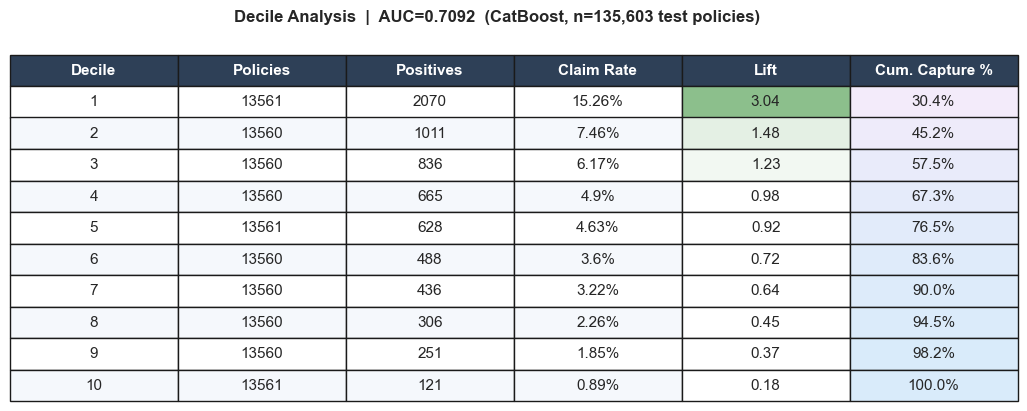

In [19]:
# Decile analysis table with colour-coded lift and cumulative capture
da = decile_analysis(y_test, cb_prob, n_bins=10)

print("=== Decile Analysis ===")
display(da[["decile", "n_policies", "n_positives", "claim_rate", "lift", "cum_capture_rate"]])

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.axis("off")

disp = da[["decile", "n_policies", "n_positives", "claim_rate", "lift", "cum_capture_rate"]].copy()
disp["claim_rate"]       = (disp["claim_rate"] * 100).round(2).astype(str) + "%"
disp["lift"]             = disp["lift"].round(2)
disp["cum_capture_rate"] = disp["cum_capture_rate"].round(1).astype(str) + "%"

col_labels = ["Decile", "Policies", "Positives", "Claim Rate", "Lift", "Cum. Capture %"]
tbl = ax.table(cellText=disp.values, colLabels=col_labels,
               cellLoc="center", loc="center", bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)

lift_vals = da["lift"].values
lift_max  = lift_vals.max()
for row_i in range(1, len(disp) + 1):
    lift_val  = lift_vals[row_i - 1]
    intensity = np.clip((lift_val - 1) / max(lift_max - 1, 0.01), 0, 1)
    tbl[row_i, 4].set_facecolor((0.55 + 0.45*(1-intensity),
                                  0.75 + 0.25*(1-intensity),
                                  0.55 + 0.45*(1-intensity)))
    ccr = da["cum_capture_rate"].values[row_i - 1] / 100
    tbl[row_i, 5].set_facecolor((0.85 + 0.15*(1-ccr), 0.92, 0.98))

for col_i in range(len(col_labels)):
    tbl[0, col_i].set_facecolor("#2E4057")
    tbl[0, col_i].set_text_props(color="white", fontweight="bold")

for row_i in range(1, len(disp) + 1):
    if row_i % 2 == 0:
        for col_i in [0, 1, 2, 3]:
            tbl[row_i, col_i].set_facecolor("#F5F8FC")

plt.suptitle(
    f"Decile Analysis  |  AUC={_roc_auc(y_test, cb_prob):.4f}  "
    f"(CatBoost, n={len(y_test):,} test policies)",
    fontsize=12, fontweight="bold"
)
fig.savefig(FIG_DIR / "02_decile_analysis.png", bbox_inches="tight", dpi=130)
plt.show()

## 9. STP Routing

In [20]:
# Apply STP routing using the best calibrated model (auto-selected by ECE)
calibrated_probs = {
    'Sigmoid':    prob_sigmoid,
    'Isotonic':   prob_isoton,
    'Beta':       prob_beta,
    'Venn-ABERS': prob_venn,
}
best_name = min(calibrated_probs, key=lambda k: calibration_metrics(y_test, calibrated_probs[k])['ece'])
best_prob = calibrated_probs[best_name]

print(f'Best calibrator by ECE: {best_name}  (ECE={calibration_metrics(y_test, best_prob)["ece"]:.4f})')

summary = stp_summary(best_prob, y_true=y_test)
print(f'=== STP Routing Summary (CatBoost + {best_name}) ===')
print(summary.to_string())

Best calibrator by ECE: Beta  (ECE=0.0005)
=== STP Routing Summary (CatBoost + Beta) ===
             n_policies   pct  claim_rate
stp_lane                                 
auto-settle      125594  92.6      0.0406
review             9843   7.3      0.1679
investigate         166   0.1      0.3554


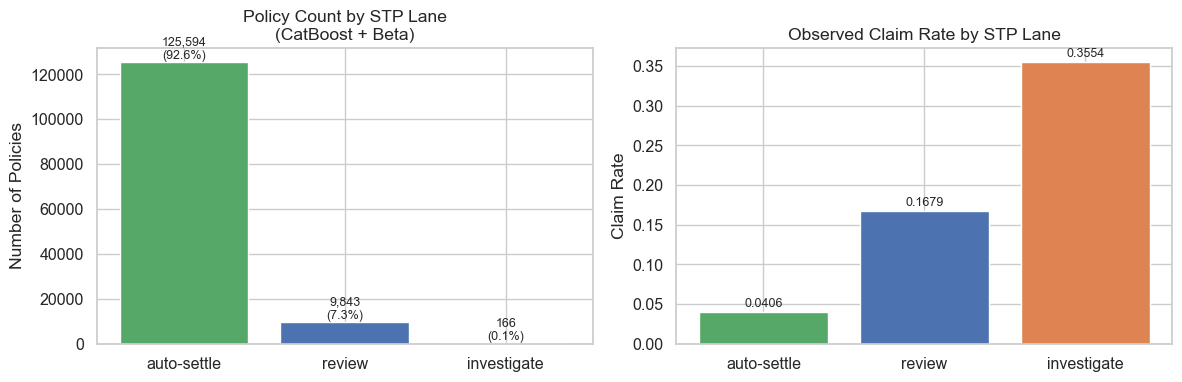

In [21]:
# Visualise lane distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

lane_order = ['auto-settle', 'review', 'investigate']
colors_lane = ['#55A868', '#4C72B0', '#DD8452']

# Policy count by lane
axes[0].bar(
    lane_order,
    [summary.loc[l, 'n_policies'] for l in lane_order],
    color=colors_lane, edgecolor='white'
)
axes[0].set_title(f'Policy Count by STP Lane\n(CatBoost + {best_name})')
axes[0].set_ylabel('Number of Policies')
for i, l in enumerate(lane_order):
    n = summary.loc[l, 'n_policies']
    p = summary.loc[l, 'pct']
    axes[0].text(i, n + 100, f'{n:,}\n({p}%)', ha='center', va='bottom', fontsize=9)

# Claim rate by lane
if 'claim_rate' in summary.columns:
    axes[1].bar(
        lane_order,
        [summary.loc[l, 'claim_rate'] for l in lane_order],
        color=colors_lane, edgecolor='white'
    )
    axes[1].set_title('Observed Claim Rate by STP Lane')
    axes[1].set_ylabel('Claim Rate')
    for i, l in enumerate(lane_order):
        cr = summary.loc[l, 'claim_rate']
        axes[1].text(i, cr + 0.002, f'{cr:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
fig.savefig(FIG_DIR / "02_stp_routing.png", bbox_inches="tight", dpi=130)
plt.show()

## 10. MLflow Logging

In [22]:
# Log the best calibrated model to MLflow
best_metrics     = classification_report_dict(y_test, best_prob)
best_cal_metrics = calibration_metrics(y_test, best_prob)

mlflow.set_experiment('claims_classification')

with mlflow.start_run(run_name='catboost_calibrated'):
    mlflow.log_params({
        'model'           : 'CatBoostClassifier',
        'calibration'     : best_name,
        'iterations'      : 866,
        'learning_rate'   : 0.088,
        'depth'           : 7,
        'l2_leaf_reg'     : 4.04,
        'scale_pos_weight': round(spw, 4),
        'train_size'      : len(X_train),
        'test_size'       : len(X_test),
        'features'        : str(all_features),
        'cat_features'    : str(CATEGORICAL_FEATURES),
        'random_state'    : RANDOM_STATE,
    })
    mlflow.log_metrics({
        'roc_auc'      : round(best_metrics['roc_auc'], 4),
        'avg_precision': round(best_metrics['avg_precision'], 4),
        'brier_score'  : round(best_metrics['brier_score'], 4),
        'cohen_kappa'  : round(best_metrics['cohen_kappa'], 4),
        'gini'         : round(best_metrics['gini'], 4),
        'ece'          : round(best_cal_metrics['ece'], 4),
        'mce'          : round(best_cal_metrics['mce'], 4),
    })
    for lane in ['auto-settle', 'review', 'investigate']:
        safe_lane = lane.replace('-', '_')
        mlflow.log_metric(f'stp_{safe_lane}_pct', float(summary.loc[lane, 'pct']))
        if 'claim_rate' in summary.columns:
            mlflow.log_metric(f'stp_{safe_lane}_claim_rate', float(summary.loc[lane, 'claim_rate']))

    run_id = mlflow.active_run().info.run_id

print(f'MLflow run logged. Run ID: {run_id}')
print(f'Best calibrator: {best_name}  AUC={best_metrics["roc_auc"]:.4f}  ECE={best_cal_metrics["ece"]:.4f}')

MLflow run logged. Run ID: 2648dedba3044871a84cf2e0dd90400e
Best calibrator: Beta  AUC=0.7077  ECE=0.0005
